In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans

In [2]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})

In [3]:
import numpy as np
import scipy.special as sp

mode_indices = [1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 14]
R_act = xr.Dataset()

for i in mode_indices:
    p     = ds[f'NACT_FRAC{i:02d}'] / 100.0      # percent -> fraction
    mu    = np.log(ds[f'NMR{i:02d}'])
    sigma = np.log(ds[f'SIGMA{i:02d}'])
    z = xr.apply_ufunc(sp.ndtri, 1 - p, dask='parallelized', output_dtypes=[float])
    R_act[f'R_act{i:02d}'] = np.exp(mu + sigma * z)

In [4]:
print(ds['SIGMA01'].attrs)
print(ds['SIGMA01'].min().compute().item(), ds['SIGMA01'].max().compute().item())

{'mdims': np.int32(1), 'units': '-', 'long_name': 'Std. dev. mode 01', 'pressure_coords': 'False', 'raw_data_path': '/proj/bolinc/users/x_sarbl/noresm_archive', 'model': 'NorESM', 'model_name': 'NorESM', 'case_name': 'OsloAero_prcp2szdst_f19_f19_noresmv211_corr', 'case': 'OsloAero_prcp2szdst_f19_f19_noresmv211_corr', 'case_name_nice': 'OsloAero_prcp2szdst_f19_f19_noresmv211_corr', 'isSectional': 'False', 'from_time': '2012-01-01', 'to_time': '2012-02-01', 'startyear': '2012', 'endyear': '2012'}
1.3273310661315918 1.815531849861145


In [5]:
R_act01

NameError: name 'R_act01' is not defined

In [6]:
# total infs
n_inf = np.isinf(R_act01).sum().compute().item()

# fraction of all points
frac_inf = (np.isinf(R_act01).sum() / R_act01.size).compute().item()
print(f"{n_inf} inf values ({frac_inf:.1%})")

# also check NaN, in case some come from p outside (0,1) rather than overflow
n_nan = np.isnan(R_act01).sum().compute().item()
print(f"inf: {n_inf}, nan: {n_nan}")

NameError: name 'R_act01' is not defined

In [7]:
import numpy as np
import scipy.special as sp

mode_indices = [1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 14]

R_act = xr.Dataset()

for i in mode_indices:
    p     = ds[f'NACT_FRAC{i:02d}']
    mu    = np.log(ds[f'NMR{i:02d}'])      # median radius (nm) -> log scale
    sigma = np.log(ds[f'SIGMA{i:02d}'])    # geometric std dev -> log scale

    z = xr.apply_ufunc(sp.ndtri, 1 - p, dask='parallelized', output_dtypes=[float])
    R_act[f'R_act{i:02d}'] = np.exp(mu + sigma * z)   # activation radius in nm

In [8]:
n_inf = np.isinf(R_act).sum(dim=[d for d in R_act.dims if d != 'mode']).compute()
print(n_inf)   # one count per mode

<xarray.Dataset> Size: 88B
Dimensions:  ()
Data variables:
    R_act01  int64 8B 3877007
    R_act02  int64 8B 3877008
    R_act04  int64 8B 3877007
    R_act05  int64 8B 3877007
    R_act06  int64 8B 3877014
    R_act07  int64 8B 3877007
    R_act08  int64 8B 3877007
    R_act09  int64 8B 3877007
    R_act10  int64 8B 4073345
    R_act12  int64 8B 4007269
    R_act14  int64 8B 4074745


In [9]:
mask = ds['FREQL'] > 0.8

R_act_masked = R_act.where(mask)   # works on the Dataset or the stacked DataArray

In [10]:
n_inf_cloud = np.isinf(R_act_masked).sum(
    dim=[d for d in R_act_masked.dims if d != 'mode']
).compute()
print(n_inf_cloud)

<xarray.Dataset> Size: 88B
Dimensions:  ()
Data variables:
    R_act01  int64 8B 0
    R_act02  int64 8B 0
    R_act04  int64 8B 0
    R_act05  int64 8B 0
    R_act06  int64 8B 0
    R_act07  int64 8B 0
    R_act08  int64 8B 0
    R_act09  int64 8B 0
    R_act10  int64 8B 58890
    R_act12  int64 8B 75811
    R_act14  int64 8B 59124


In [11]:
R_act_finite.compute().median(dim=[d for d in R_act_finite.dims if d != 'mode'])

NameError: name 'R_act_finite' is not defined

In [12]:
for i in [1, 2, 4, 10, 12, 14]:
    da = R_act_masked[f'R_act{i:02d}']
    da_f = da.where(np.isfinite(da)).compute()   # load this one mode
    print(i, float(da_f.min()), float(da_f.median()), float(da_f.max()))

1 2.0866189002990723 28.059690475463867 178.1221160888672
2 1.978822112083435 40.72950553894043 400.6165771484375
4 71.001708984375 76.07414245605469 76.76620483398438
10 4478.49169921875 8293.3671875 9162.2978515625
12 3.416835069656372 17.444683074951172 539.2664184570312
14 5.7771477699279785 24.41335105895996 88.26290893554688


In [13]:
for v in ['NMR04', 'SIGMA04', 'NACT_FRAC04']:
    da = ds[v].where(ds['FREQL'] > 0.8).compute()
    print(v, float(da.min()), float(da.median()), float(da.max()))

NMR04 39.00996780395508 64.63334655761719 658.7386474609375
SIGMA04 1.0009211301803589 1.7475769519805908 2.0029120445251465
NACT_FRAC04 0.4269820749759674 89.55762481689453 100.0


In [14]:
for v in ['NMR10', 'SIGMA10', 'NACT_FRAC10']:
    da = ds[v].where(ds['FREQL'] > 0.8).compute()
    print(v, float(da.min()), float(da.median()), float(da.max()))

NMR10 747.0 750.8621215820312 1003.9791259765625
SIGMA10 1.4846428632736206 1.602767825126648 1.6055357456207275
NACT_FRAC10 0.0 100.0 100.0


In [15]:
i = 4
p     = ds[f'NACT_FRAC{i:02d}'] / 100.0
mu    = np.log(ds[f'NMR{i:02d}'])
sigma = np.log(ds[f'SIGMA{i:02d}'])
z = xr.apply_ufunc(sp.ndtri, 1 - p, dask='parallelized', output_dtypes=[float])
R_act04 = np.exp(mu + sigma * z)

# masked to cloud, finite only, then range
da = R_act04.where(ds['FREQL'] > 0.8)
da = da.where(np.isfinite(da)).compute()
print(float(da.min()), float(da.median()), float(da.max()))

0.0 39.81874465942383 238.40647888183594


Activation radius summary at SMR-II  (nm, cloud & finite only)
 mode          n        min     median       mean        max
    1      11125      17.72      60.03      60.96     139.82
    2      11125       0.00      57.86      72.95     268.22
    4      11125       0.00      41.23      39.78     161.46
    5      11125       0.00      39.90      40.31     125.89
    6      11125       0.00      56.13      56.30     167.40
    7      11125       0.00      97.67     142.66    1737.69
    8      11125       0.00      30.90      29.84     100.38
    9      11125       0.00      27.24      21.48      93.98
   10       6271       0.00       0.00       0.87      93.69
   12       4854      14.83      41.10      42.28     189.96
   14       6271      26.08      75.79      76.41     191.20


/tmp/ipykernel_897477/248791600.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=[f"{m:02d}" for m in MODE_INDICES],


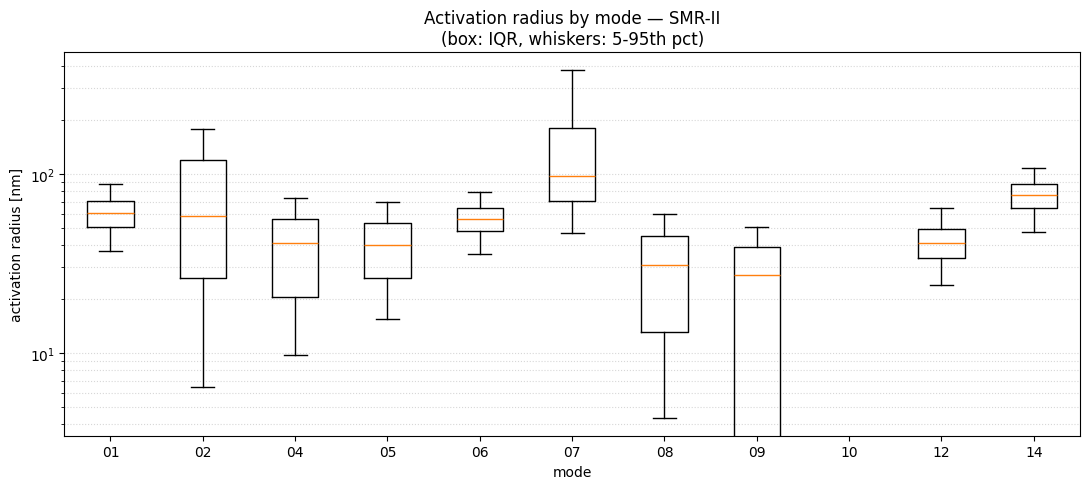

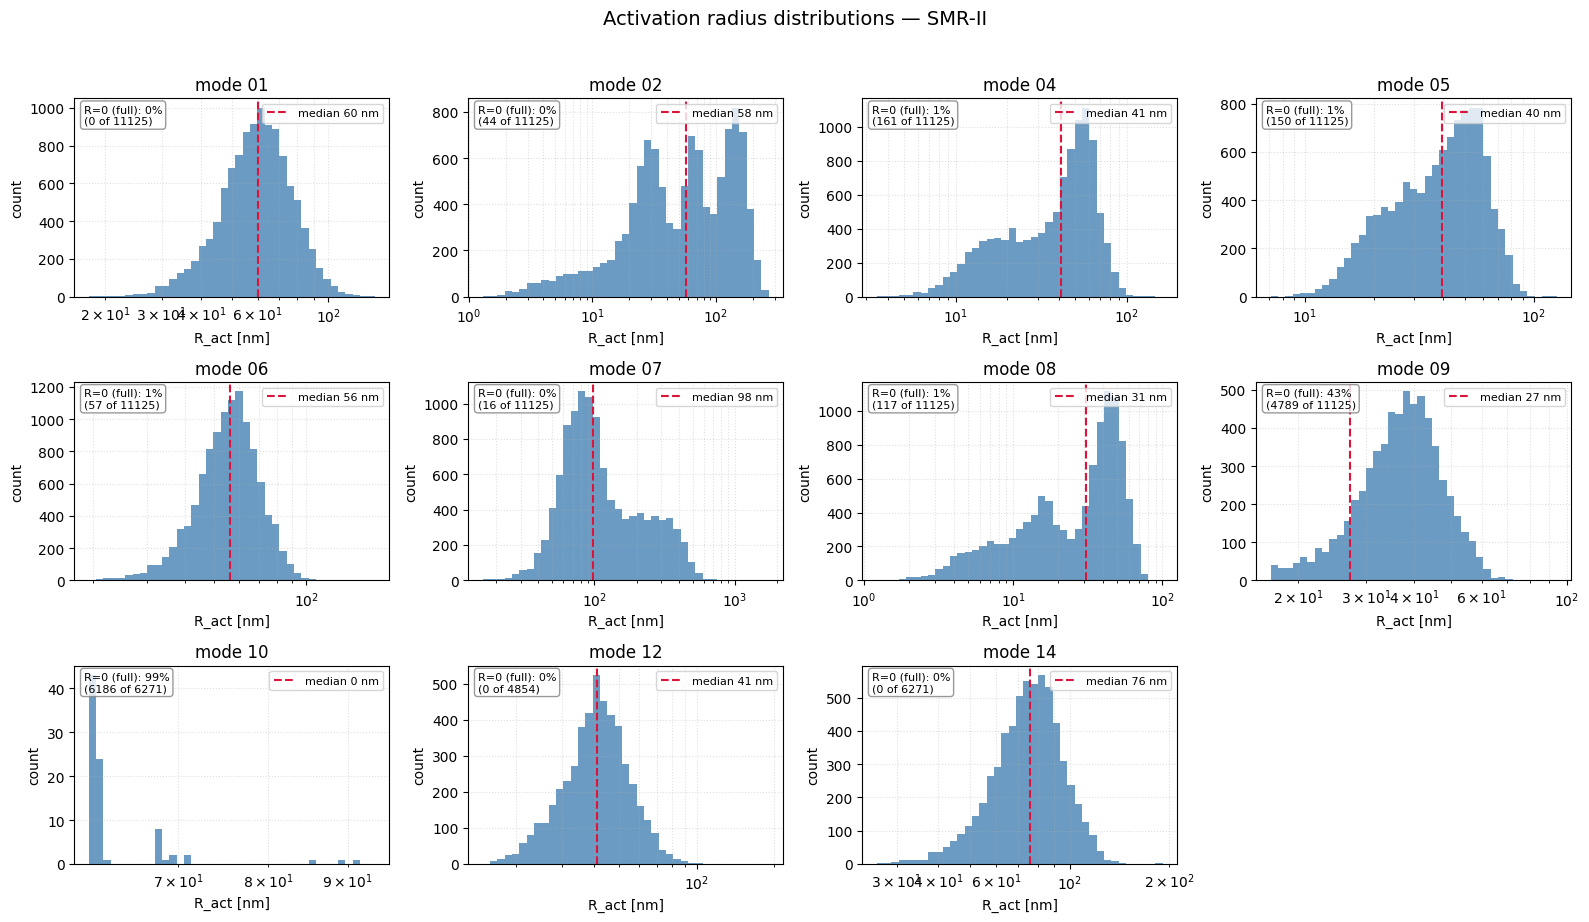

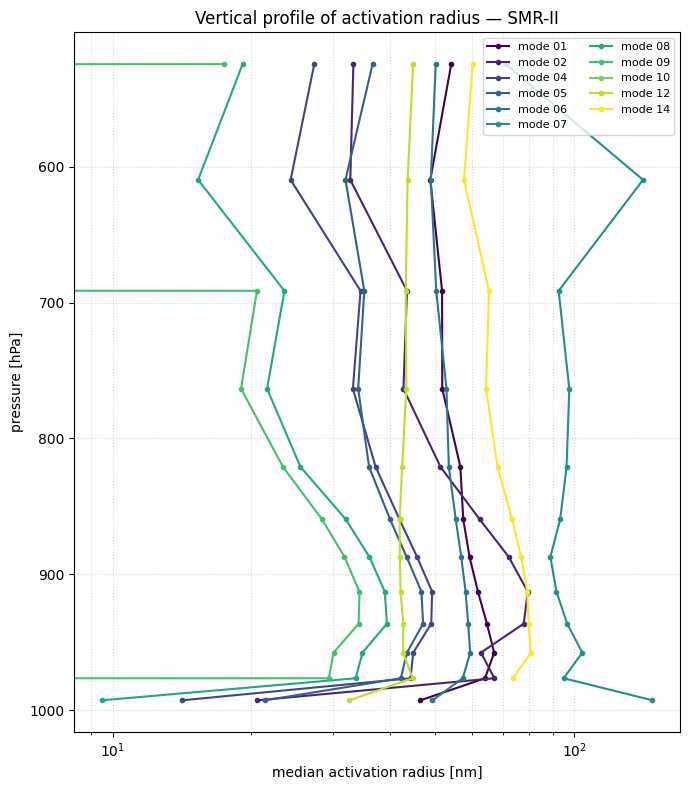

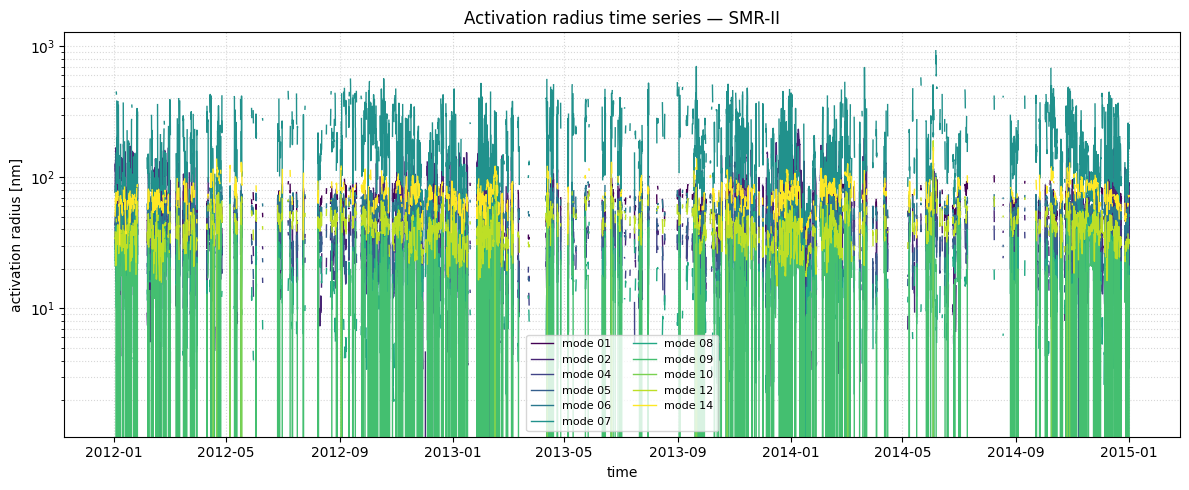


Done. Figures saved with prefix 'Ract_' for station SMR-II


In [17]:
"""
Activation radius analysis for a single station (e.g. 'SMR-II').

Assumes `ds` already exists in memory and contains, for each mode i:
    NMR{i:02d}        number median radius  [nm]   (linear, NOT log-space)
    SIGMA{i:02d}      geometric std dev     [-]    (sigma_g, ~1.2-2.5)
    NACT_FRAC{i:02d}  activated fraction    [%]    (0-100, NOT 0-1)
and a cloud-frequency field FREQL, plus a vertical coordinate ('lev').

Three input corrections (all confirmed during debugging):
    mu    = log(NMR)        # nm radius -> log-space location
    sigma = log(SIGMA)      # geometric std dev -> log-space width
    p     = NACT_FRAC / 100 # percent -> fraction

Activation radius (radius exceeded by fraction p of the mode):
    R_act = exp( mu + sigma * Phi^-1(1 - p) )

Endpoints are physical: p=1 -> R_act=0 (all activate); p=0 -> R_act=inf
(nothing activates). For plotting we mask BOTH zeros and infs.
"""

import numpy as np
import xarray as xr
import scipy.special as sp
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
STATION       = "SMR-II"
FREQL_THRESH  = 0.8                                  # liquid-cloud frequency cut
MODE_INDICES  = [1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 14] # NorESM/OsloAero modes
OUTDIR        = "."                                   # where figures are saved

# ----------------------------------------------------------------------
# 1. Select station
# ----------------------------------------------------------------------
dss = ds.sel(station=STATION)

# ----------------------------------------------------------------------
# 2. Compute activation radius per mode  (with the three corrections)
# ----------------------------------------------------------------------
def activation_radius(dset, i):
    """R_act for mode i, in nm. Lazy (dask-friendly)."""
    p     = dset[f"NACT_FRAC{i:02d}"] / 100.0     # percent -> fraction
    mu    = np.log(dset[f"NMR{i:02d}"])           # radius (nm) -> log scale
    sigma = np.log(dset[f"SIGMA{i:02d}"])         # geometric std dev -> log scale
    z = xr.apply_ufunc(
        sp.ndtri, 1 - p,
        dask="parallelized", output_dtypes=[float],
    )
    return np.exp(mu + sigma * z)                  # nm

# Stack all modes along a 'mode' dimension
R_act = xr.concat(
    [activation_radius(dss, i) for i in MODE_INDICES],
    dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"),
)
R_act.name = "R_act"
R_act.attrs["units"] = "nm"
R_act.attrs["long_name"] = "activation radius"

# ----------------------------------------------------------------------
# 3. Mask: liquid cloud only, drop zeros and infs (and NaNs)
# ----------------------------------------------------------------------
cloud_mask = dss["FREQL"] > FREQL_THRESH
R_clean = R_act.where(cloud_mask)
# Keep zeros (R_act = 0 means the whole mode activates — a real value).
# Mask only inf (nothing activates) and nan. np.isfinite is False for both
# inf and nan, and True for 0.0, so this keeps zeros and drops inf/nan.
R_clean = R_clean.where(np.isfinite(R_clean))

# Load into memory once (single station -> small enough)
R_clean = R_clean.compute()

# Convenience: per-mode 1-D arrays of finite values (numpy), for histograms
def mode_values(m):
    a = R_clean.sel(mode=m).values.ravel()
    return a[np.isfinite(a)]

# ----------------------------------------------------------------------
# 4. Quick numeric summary
# ----------------------------------------------------------------------
print(f"Activation radius summary at {STATION}  (nm, cloud & finite only)")
print(f"{'mode':>5} {'n':>10} {'min':>10} {'median':>10} {'mean':>10} {'max':>10}")
for m in MODE_INDICES:
    v = mode_values(m)
    if v.size:
        print(f"{m:>5} {v.size:>10d} {v.min():>10.2f} "
              f"{np.median(v):>10.2f} {v.mean():>10.2f} {v.max():>10.2f}")
    else:
        print(f"{m:>5} {0:>10d} {'--':>10} {'--':>10} {'--':>10} {'--':>10}")

# ----------------------------------------------------------------------
# FIGURE 1 — Distributions per mode (box plot + histogram grid)
# ----------------------------------------------------------------------
# 1a. Box plot across modes (log y-axis spans the wide range)
fig, ax = plt.subplots(figsize=(11, 5))
data_box = [mode_values(m) for m in MODE_INDICES]
data_box = [v if v.size else np.array([np.nan]) for v in data_box]
ax.boxplot(data_box, labels=[f"{m:02d}" for m in MODE_INDICES],
           showfliers=False, whis=(5, 95))
ax.set_yscale("log")
ax.set_xlabel("mode")
ax.set_ylabel("activation radius [nm]")
ax.set_title(f"Activation radius by mode — {STATION}\n(box: IQR, whiskers: 5-95th pct)")
ax.grid(True, which="both", axis="y", ls=":", alpha=0.5)
fig.tight_layout()
fig.savefig(f"{OUTDIR}/Ract_box_by_mode_{STATION}.png", dpi=150)

# 1b. Histogram grid (one panel per mode, log-spaced bins)
ncol = 4
nrow = int(np.ceil(len(MODE_INDICES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, m in zip(axes, MODE_INDICES):
    v = mode_values(m)
    if v.size:
        # Zeros (full activation) can't sit on a log axis. Split them out,
        # histogram the positive values on log bins, and report the zero
        # count separately so the full-activation cases aren't lost.
        n_zero = int(np.sum(v == 0))
        vpos = v[v > 0]
        if vpos.size:
            bins = np.logspace(np.log10(vpos.min()),
                               np.log10(vpos.max()), 40)
            ax.hist(vpos, bins=bins, color="steelblue", alpha=0.8)
            ax.set_xscale("log")
            ax.axvline(np.median(v), color="crimson", ls="--", lw=1.5,
                       label=f"median {np.median(v):.0f} nm")
        # annotate fraction fully activated (R_act = 0)
        frac_zero = n_zero / v.size
        ax.text(0.03, 0.97,
                f"R=0 (full): {frac_zero:.0%}\n({n_zero} of {v.size})",
                transform=ax.transAxes, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
        ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"mode {m:02d}")
    ax.set_xlabel("R_act [nm]")
    ax.set_ylabel("count")
    ax.grid(True, which="both", ls=":", alpha=0.4)
# hide any unused panels
for ax in axes[len(MODE_INDICES):]:
    ax.set_visible(False)
fig.suptitle(f"Activation radius distributions — {STATION}", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(f"{OUTDIR}/Ract_hist_grid_{STATION}.png", dpi=150, bbox_inches="tight")

# ----------------------------------------------------------------------
# FIGURE 2 — Vertical profile vs pressure level
# ----------------------------------------------------------------------
# Median over time at each level. Requires a 'lev' coord/dim and that
# 'lev' holds pressure (hPa). Adjust the dim name if yours differs.
profile_dim = "time"   # dim(s) to reduce over, keeping 'lev'
if "lev" in R_clean.dims:
    other = [d for d in R_clean.dims if d not in ("mode", "lev")]
    R_prof = R_clean.median(dim=other)          # dims: (mode, lev)
    lev = dss["lev"].values if "lev" in dss else R_clean["lev"].values

    fig, ax = plt.subplots(figsize=(7, 8))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(MODE_INDICES)))
    for c, m in zip(cmap, MODE_INDICES):
        prof = R_prof.sel(mode=m).values
        ax.plot(prof, lev, "-o", ms=3, color=c, label=f"mode {m:02d}")
    ax.set_xscale("log")
    ax.invert_yaxis()                            # surface at bottom
    ax.set_xlabel("median activation radius [nm]")
    ax.set_ylabel("pressure [hPa]")
    ax.set_title(f"Vertical profile of activation radius — {STATION}")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/Ract_profile_{STATION}.png", dpi=150)
else:
    print("No 'lev' dimension found — skipping vertical profile figure.")

# ----------------------------------------------------------------------
# FIGURE 3 — Time series
# ----------------------------------------------------------------------
# Reduce over any non-time, non-mode dims (e.g. lev) by median, then plot
# each mode through time.
if "time" in R_clean.dims:
    reduce_dims = [d for d in R_clean.dims if d not in ("mode", "time")]
    R_ts = R_clean.median(dim=reduce_dims) if reduce_dims else R_clean

    fig, ax = plt.subplots(figsize=(12, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(MODE_INDICES)))
    for c, m in zip(cmap, MODE_INDICES):
        ax.plot(R_ts["time"].values, R_ts.sel(mode=m).values,
                "-", lw=1, color=c, label=f"mode {m:02d}")
    ax.set_yscale("log")
    ax.set_xlabel("time")
    ax.set_ylabel("activation radius [nm]")
    ax.set_title(f"Activation radius time series — {STATION}")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/Ract_timeseries_{STATION}.png", dpi=150)
else:
    print("No 'time' dimension found — skipping time-series figure.")

plt.show()
print("\nDone. Figures saved with prefix 'Ract_' for station", STATION)


In [18]:
# === Cell 1: NCONC-weighted bulk activation diameter ===
# D_weighted = sum_i(NCONC_i * 2*R_act_i) / sum_i(NCONC_i)
#   inf modes (non-activating) -> dropped from both sums
#   R=0 modes (fully activating) -> kept, pull the mean down

# Re-mask as the figures: cloud only, finite (keeps 0, drops inf/nan)
R_act_masked = R_act.where(cloud_mask)
R_act_masked = R_act_masked.where(np.isfinite(R_act_masked))

# NCONC weights along the same 'mode' dim
NCONC = xr.concat(
    [dss[f"NCONC{i:02d}"] for i in MODE_INDICES],
    dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"),
)

D_act = 2.0 * R_act_masked                      # diameter per mode [nm]
NCONC_eff = NCONC.where(np.isfinite(D_act))     # null weight where non-activating

numer = (NCONC_eff * D_act).sum(dim="mode", skipna=True)
denom = NCONC_eff.sum(dim="mode", skipna=True)

D_act_weighted = (numer / denom.where(denom > 0)).compute()
D_act_weighted.name = "D_act_weighted"
D_act_weighted.attrs.update(units="nm",
                            long_name="NCONC-weighted bulk activation diameter")

dw = D_act_weighted.values.ravel()
dw = dw[np.isfinite(dw)]
print(f"D_act_weighted at {STATION} (nm): n={dw.size}  min={dw.min():.2f}  "
      f"median={np.median(dw):.2f}  mean={dw.mean():.2f}  max={dw.max():.2f}")

D_act_weighted at SMR-II (nm): n=11125  min=27.36  median=119.74  mean=118.57  max=286.96


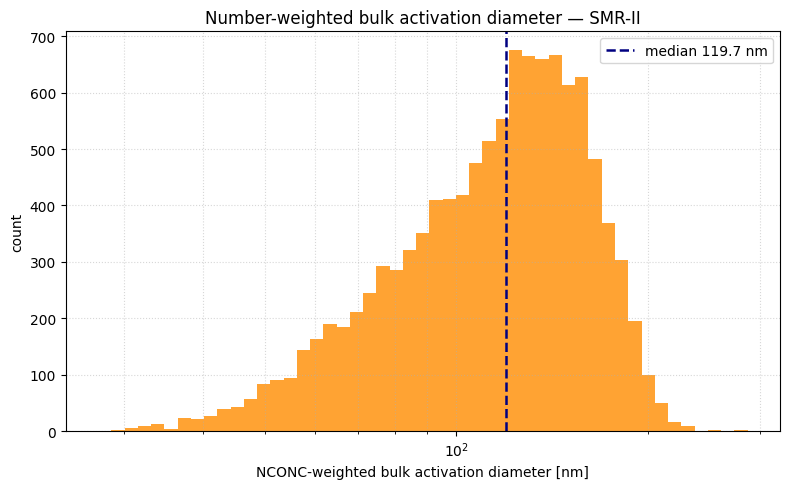

In [19]:
# === Cell 2: distribution figure ===
fig, ax = plt.subplots(figsize=(8, 5))
pos = dw[dw > 0]
n_zero = int(np.sum(dw == 0))
if pos.size:
    bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 50)
    ax.hist(pos, bins=bins, color="darkorange", alpha=0.8)
    ax.set_xscale("log")
    ax.axvline(np.median(dw), color="navy", ls="--", lw=1.8,
               label=f"median {np.median(dw):.1f} nm")
if n_zero:
    ax.text(0.03, 0.97, f"fully activated (D=0): {n_zero/dw.size:.1%}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
ax.set_xlabel("NCONC-weighted bulk activation diameter [nm]")
ax.set_ylabel("count")
ax.set_title(f"Number-weighted bulk activation diameter — {STATION}")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

In [20]:
D_act_weighted

<xarray.DataArray 'D_act_weighted' (time: 8761, lev: 32)> Size: 2MB
array([[         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       ...,
       [         nan,          nan,          nan, ...,          nan,
        154.19275568,  81.66705871],
       [         nan,          nan,          nan, ...,          nan,
        156.21511073,  80.51278625],
       [         nan,          nan,          nan, ...,          nan,
                 nan,  78.66182185]], shape=(8761, 32))
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
    station  <U8 32B 'SMR-II'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Attributes:
    units:      nm
    long_name:  NCONC-weighted bulk activation diameter

In [21]:
# === Cell 1: compute NCONC-weighted bulk activation diameter for every station ===

def weighted_Dact_for_station(station):
    """NCONC-weighted bulk activation diameter [nm] for one station.
    Returns a 1-D numpy array of finite values (zeros kept, inf/nan dropped)."""
    dss = ds.sel(station=station)

    # R_act per mode (the three corrections), stacked along 'mode'
    def activation_radius(i):
        p     = dss[f"NACT_FRAC{i:02d}"] / 100.0
        mu    = np.log(dss[f"NMR{i:02d}"])
        sigma = np.log(dss[f"SIGMA{i:02d}"])
        z = xr.apply_ufunc(sp.ndtri, 1 - p,
                           dask="parallelized", output_dtypes=[float])
        return np.exp(mu + sigma * z)

    R = xr.concat([activation_radius(i) for i in MODE_INDICES],
                  dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"))

    # cloud mask + finite (keep 0, drop inf/nan)
    cloud = dss["FREQL"] > FREQL_THRESH
    R = R.where(cloud)
    R = R.where(np.isfinite(R))

    NCONC = xr.concat([dss[f"NCONC{i:02d}"] for i in MODE_INDICES],
                      dim=xr.DataArray(MODE_INDICES, dims="mode", name="mode"))

    D = 2.0 * R                                  # diameter per mode
    Nw = NCONC.where(np.isfinite(D))             # drop non-activating modes
    numer = (Nw * D).sum(dim="mode", skipna=True)
    denom = Nw.sum(dim="mode", skipna=True)
    Dw = (numer / denom.where(denom > 0)).compute()

    arr = Dw.values.ravel()
    return arr[np.isfinite(arr)]

stations = list(ds["station"].values)
Dact_by_station = {}
for st in stations:
    try:
        Dact_by_station[st] = weighted_Dact_for_station(st)
        v = Dact_by_station[st]
        print(f"{str(st):>12}: n={v.size:>7d}  median={np.median(v):7.2f} nm"
              if v.size else f"{str(st):>12}: no valid points")
    except KeyError as e:
        print(f"{str(st):>12}: skipped (missing {e})")
        Dact_by_station[st] = np.array([])

         ZEP: n=  21172  median=  74.50 nm
      SMR-II: n=  11125  median= 119.74 nm
        ATTO: n=   2630  median= 199.74 nm
         MHD: n=  10454  median= 103.16 nm
         SGP: n=   1326  median= 127.24 nm
         CHC: n=  24759  median= 186.60 nm
      BIR-II: n=   9308  median= 110.04 nm
         PAL: n=  12323  median= 110.37 nm
    Vavihill: n=   6524  median= 115.45 nm
         JFJ: n=  10437  median= 107.64 nm
         FKL: n=    537  median= 122.17 nm
     SMEAR-I: n=  13804  median= 109.48 nm
      Villum: n=   7727  median=  68.68 nm
       Izana: n=   2214  median= 122.13 nm
    Maldives: n=    614  median= 125.01 nm


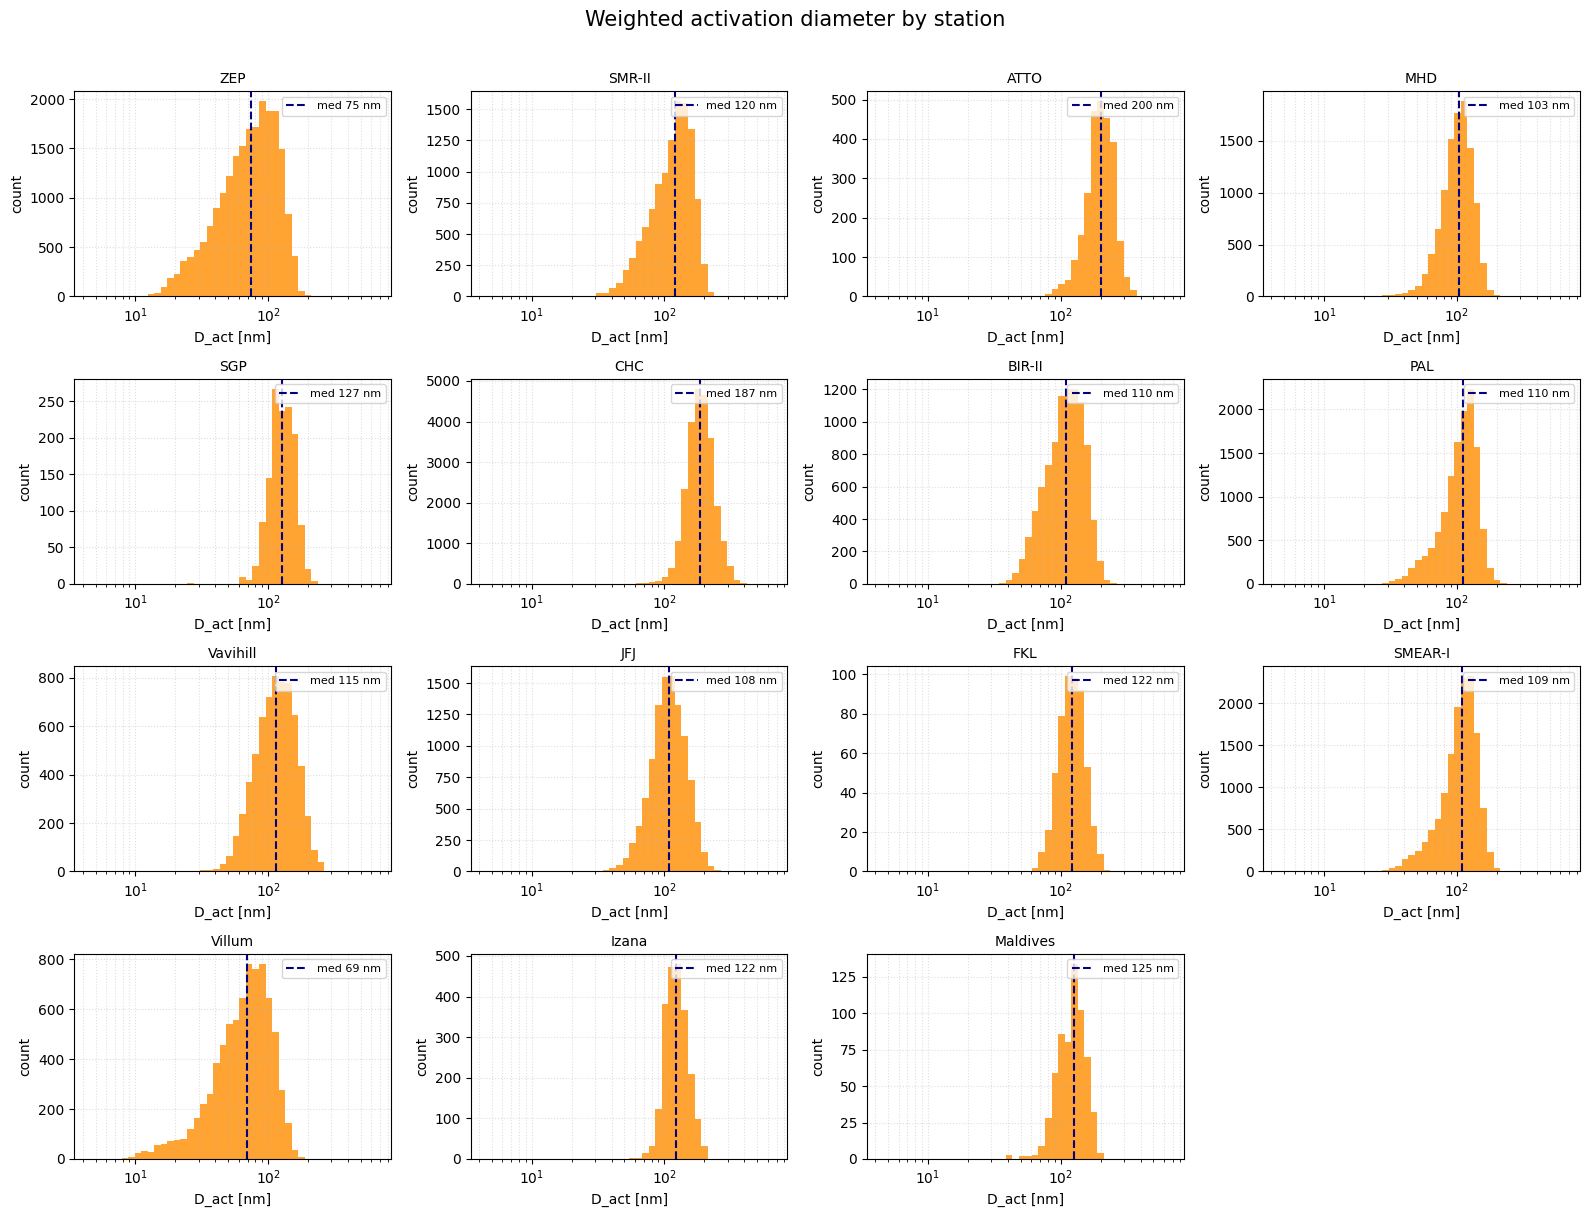

In [23]:
# === Cell 2: 15-panel histogram grid ===

stations_plot = [s for s in stations if Dact_by_station[s].size]
ncol = 4
nrow = int(np.ceil(len(stations_plot) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
axes = np.atleast_1d(axes).ravel()

# shared log bins across all stations for comparability
allpos = np.concatenate([Dact_by_station[s][Dact_by_station[s] > 0]
                         for s in stations_plot])
bins = np.logspace(np.log10(allpos.min()), np.log10(allpos.max()), 45)

for ax, st in zip(axes, stations_plot):
    v = Dact_by_station[st]
    pos = v[v > 0]
    n_zero = int(np.sum(v == 0))
    if pos.size:
        ax.hist(pos, bins=bins, color="darkorange", alpha=0.8)
        ax.set_xscale("log")
        ax.axvline(np.median(v), color="navy", ls="--", lw=1.5,
                   label=f"med {np.median(v):.0f} nm")
        ax.legend(fontsize=8, loc="upper right")
    if n_zero:
        ax.text(0.03, 0.97, f"D=0: {n_zero/v.size:.0%}",
                transform=ax.transAxes, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
    ax.set_title(str(st), fontsize=10)
    ax.set_xlabel("D_act [nm]")
    ax.set_ylabel("count")
    ax.grid(True, which="both", ls=":", alpha=0.4)

for ax in axes[len(stations_plot):]:
    ax.set_visible(False)

fig.suptitle("Weighted activation diameter by station",
             y=1.01, fontsize=15)
fig.tight_layout()
plt.show()

In [25]:
Dact_by_station

{np.str_('ZEP'): array([135.97235573, 138.39181912,  77.83986051, ...,  39.64587445,
         41.07458668,  39.26644957], shape=(21172,)),
 np.str_('SMR-II'): array([ 85.20965081, 114.16390041, 142.596712  , ..., 156.21511073,
         80.51278625,  78.66182185], shape=(11125,)),
 np.str_('ATTO'): array([163.39899213, 201.67569745, 156.13070707, ..., 240.77288152,
        225.16679299, 225.83781891], shape=(2630,)),
 np.str_('MHD'): array([125.24237474,  65.6995289 ,  78.09161907, ...,  90.02876083,
         89.07047823, 100.11103316], shape=(10454,)),
 np.str_('SGP'): array([113.11043253, 113.99041824, 124.22477019, ..., 129.83098298,
        165.58514901,  93.19901272], shape=(1326,)),
 np.str_('CHC'): array([158.3501305 , 193.95448876, 169.57217937, ..., 215.27657925,
        220.19192273, 228.10250215], shape=(24759,)),
 np.str_('BIR-II'): array([ 54.54960365, 165.85066293, 166.23905792, ..., 171.84502199,
        109.25655014, 105.25988414], shape=(9308,)),
 np.str_('PAL'): array(